# DKD + Dual MLP-Learnable Temperatures (CTKD-style) — CIFAR-100

---

### Method Summary

This notebook extends **Decoupled Knowledge Distillation** (Zhao et al., CVPR 2022) with
**dual MLP-driven learnable temperatures** inspired by CTKD (Li et al., ECCV 2022).
Instead of a single scalar per temperature, each temperature is produced by a small
two-layer MLP that takes the normalised training-progress scalar $p \in [0,1]$ as input.
This allows each temperature to follow a richer, non-monotone trajectory conditioned on
how far training has progressed.

Two independent MLP heads — one for TCKD, one for NCKD — each output a scalar $\phi$
that is sigmoid-constrained to $[\tau_{min}, \tau_{max}]$:

$$\tau_{TCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{TCKD}(p)\bigr)$$

$$\tau_{NCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{NCKD}(p)\bigr)$$

A Gradient Reversal Layer (GRL) is applied to the MLP output before sigmoid, so both
temperatures are pushed adversarially to maximise the loss while the student minimises it.

$$\mathcal{L}_{TCKD} = \text{BCE}\bigl(\sigma(z^T / \tau_{TCKD}),\; \sigma(z^S / \tau_{TCKD})\bigr)$$

$$\mathcal{L}_{NCKD} = \text{KL}\bigl(\hat{p}^T(\tau_{NCKD}) \| \hat{p}^S(\tau_{NCKD})\bigr)$$

$$\mathcal{L} = \mathcal{L}_{CE}^{\text{smooth}} + \alpha \cdot \mathcal{L}_{TCKD} + \beta \cdot \mathcal{L}_{NCKD}$$

---
**Teacher:** ResNet-18 loaded from `checkpoints/b1_resnet18_teacher_cifar100.pth`  
**Student:** MobileNetV2 trained from scratch (no pretrained weights)  
**Training regime:** SGD + Nesterov, CosineAnnealingLR T_max=125 eta_min=1e-4, lr=0.05, wd=1e-4  
**Checkpoint:** `b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth`


## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

print(f'Device      : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'PyTorch     : {torch.__version__}')
print(f'Mixed prec. : {USE_AMP}')


Device      : cuda
GPU         : Tesla T4
PyTorch     : 2.10.0+cu128
Mixed prec. : True


## 2. Configuration

In [2]:
import zipfile, os
from pathlib import Path

# ── Where Kaggle extracted your dataset ───────────────────────────────────
EXTRACTED_DIR = Path('/kaggle/input/datasets/subhankashif/bestteach/best_teacher')

# ── Re-pack the folder into a zip in /kaggle/working ──────────────────────
REPACKED_ZIP = Path('/kaggle/working/best_teacher_repacked.zip')

if not REPACKED_ZIP.exists():
    print(f'Re-packing {EXTRACTED_DIR} → {REPACKED_ZIP} ...')
    with zipfile.ZipFile(REPACKED_ZIP, 'w') as zf:
        for file in sorted(EXTRACTED_DIR.rglob('*')):
            if file.is_file():
                # arcname must recreate the  best_teacher/...  structure
                arcname = 'best_teacher/' + str(file.relative_to(EXTRACTED_DIR))
                zf.write(file, arcname)
    print(f'Done. Size: {REPACKED_ZIP.stat().st_size / 1e6:.1f} MB')
else:
    print(f'Repacked zip already exists: {REPACKED_ZIP}')

# ── Now torch.load works normally ─────────────────────────────────────────
raw = torch.load(str(REPACKED_ZIP), map_location=DEVICE, weights_only=False)
print(type(raw), raw.keys() if isinstance(raw, dict) else '')

Re-packing /kaggle/input/datasets/subhankashif/bestteach/best_teacher → /kaggle/working/best_teacher_repacked.zip ...
Done. Size: 44.9 MB
<class 'collections.OrderedDict'> odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn

In [3]:
DATA_DIR = Path('./data')
CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPT = REPACKED_ZIP

NUM_CLASSES = 100
CIFAR_MEAN  = (0.5071, 0.4867, 0.4408)
CIFAR_STD   = (0.2675, 0.2565, 0.2761)

# -- Training schedule (matches retrained baseline notebook) ------------------
EPOCHS     = 125
BATCH_SIZE = 128

LR           = 0.05    # CHANGED: was 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4    # CHANGED: was 5e-4
# Scheduler: CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
# LR_MILESTONES / LR_GAMMA removed — no longer used

# -- DKD loss weights ---------------------------------------------------------
ALPHA = 1.0   # weight on TCKD loss  (unchanged)
BETA  = 8.0   # weight on NCKD loss  (CHANGED: was 1.0, then 2.0)

# -- Temperature constraints --------------------------------------------------
TAU_MIN = 2.0    # sigmoid lower bound
TAU_MAX = 10.0   # sigmoid upper bound

# -- Temperature MLP architecture ---------------------------------------------
# Each temperature MLP: Linear(NUM_CLASSES, H) -> ReLU -> Linear(H, H) -> ReLU -> Linear(H, 1)
# Input is the mean-pooled student logits (shape [C]) — rich signal about current predictions
MLP_HIDDEN_DIM = 64   # hidden units per temperature MLP (wider since input is NUM_CLASSES=100)

# -- Temperature learning rate (separate param group) -------------------------
LR_TEMP = 1e-3

# -- GRL lambda schedule ------------------------------------------------------
GRL_LAMBDA_MAX = 1.0

# CE loss: label_smoothing=0.1 -- see Loss section

print('Configuration loaded.')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR             : {LR}  (was 0.1)')
print(f'  Weight decay   : {WEIGHT_DECAY}  (was 5e-4)')
print(f'  Scheduler      : CosineAnnealingLR T_max={EPOCHS} eta_min=1e-4  (was MultiStepLR)')
print(f'  alpha / beta   : {ALPHA} / {BETA}  (beta was 1.0)')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per temperature head)')
print(f'  LR_TEMP        : {LR_TEMP}')
print(f'  GRL lambda max : {GRL_LAMBDA_MAX}')
print(f'  CE loss        : label_smoothing=0.1  (was 0.0)')


Configuration loaded.
  Epochs         : 125
  Batch size     : 128
  LR             : 0.05  (was 0.1)
  Weight decay   : 0.0001  (was 5e-4)
  Scheduler      : CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
  alpha / beta   : 1.0 / 8.0  (beta was 1.0)
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per temperature head)
  LR_TEMP        : 0.001
  GRL lambda max : 1.0
  CE loss        : label_smoothing=0.1  (was 0.0)


## 3. Data Pipeline — CIFAR-100

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),   # matches retrained baseline notebook
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = datasets.CIFAR100(root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_ds  = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds):,} samples  ({len(train_loader)} batches)')
print(f'Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)')
print(f'Image : {train_ds[0][0].shape}  (C x H x W)')


100%|██████████| 169M/169M [00:01<00:00, 92.3MB/s] 


Train : 50,000 samples  (391 batches)
Test  : 10,000 samples  (40 batches)
Image : torch.Size([3, 32, 32])  (C x H x W)


## 4. Model Definitions

### 4.1 Teacher — ResNet-18

Teacher-loading logic identical to the original DKD+CTKD notebook: auto-detects conv1 kernel size,
handles both CIFAR-adapted (3×3) and standard (7×7) checkpoints, and strips DataParallel prefixes.


In [5]:
def build_resnet18_cifar(num_classes):
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m


def build_resnet18_standard(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, num_classes)
    return m


def load_teacher(ckpt_path, num_classes, device):
    """
    Robust teacher loader — identical to the original DKD+CTKD notebook.
    Handles {'state_dict': ..., ...} and raw state_dict formats.
    Strips 'module.' prefix from DataParallel saves.
    Auto-detects conv1 architecture from checkpoint weight tensor shape.
    """
    raw   = torch.load(ckpt_path, map_location=device)
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    conv1_kernel = state['conv1.weight'].shape[2]

    if conv1_kernel == 3:
        print(f'  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18')
        model = build_resnet18_cifar(num_classes).to(device)
    else:
        print(f'  Detected conv1 kernel=7x7 -> building standard ResNet-18')
        model = build_resnet18_standard(num_classes).to(device)

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  [WARN] Missing keys   : {missing}')
    if unexpected:
        print(f'  [WARN] Unexpected keys: {unexpected}')

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    reported = raw.get('top1', raw.get('val_top1', 'N/A')) if isinstance(raw, dict) else 'N/A'
    print(f'Teacher loaded from  : {ckpt_path}')
    print(f'  conv1 kernel       : {conv1_kernel}x{conv1_kernel}')
    print(f'  Checkpoint top-1   : {reported}')
    return model


teacher = load_teacher(TEACHER_CKPT, NUM_CLASSES, DEVICE)
print(f'  Trainable params   : {sum(p.numel() for p in teacher.parameters() if p.requires_grad)}')
print('  Teacher is frozen -- will never update during training.')


  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18
Teacher loaded from  : /kaggle/working/best_teacher_repacked.zip
  conv1 kernel       : 3x3
  Checkpoint top-1   : N/A
  Trainable params   : 0
  Teacher is frozen -- will never update during training.


### 4.2 Student — MobileNetV2 (from scratch)

In [6]:
def build_mobilenetv2_cifar(num_classes):
    """MobileNetV2 for 32x32 CIFAR, trained from scratch."""
    m = models.mobilenet_v2(weights=None)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, num_classes),
    )
    return m


student = build_mobilenetv2_cifar(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in student.parameters()) / 1e6
trainable_p = sum(p.numel() for p in student.parameters() if p.requires_grad) / 1e6
print(f'Student : MobileNetV2  |  {total_p:.2f}M total  |  {trainable_p:.2f}M trainable')
print('Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.')


Student : MobileNetV2  |  2.35M total  |  2.35M trainable
Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.


## 5. Gradient Reversal Layer (GRL)

Identical to the original DKD+CTKD notebook.
Forward is identity; backward multiplies gradients by $-\lambda$.

$\lambda$ is annealed from 0 to `GRL_LAMBDA_MAX` via the sigmoid schedule from CTKD:

$$\lambda(p) = \frac{2 \cdot \lambda_{max}}{1 + e^{-10p}} - \lambda_{max}, \quad p = \frac{\text{epoch}}{\text{total\_epochs}}$$


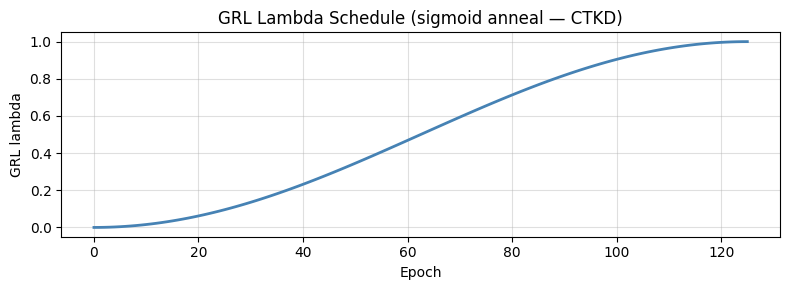

lambda at epoch   0 : 0.0000
lambda at epoch   31 : 0.1442
lambda at epoch   62 : 0.4937
lambda at epoch 125 : 1.0000


In [14]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, grl_lambda):
        ctx.save_for_backward(torch.tensor(grl_lambda))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        grl_lambda, = ctx.saved_tensors
        return -grl_lambda.item() * grad_output, None


def grad_reverse(x, grl_lambda):
    return GradientReversalFunction.apply(x, grl_lambda)


def compute_grl_lambda(epoch, total_epochs, lambda_max=GRL_LAMBDA_MAX):
    """Sigmoid-annealed GRL schedule from CTKD (Li et al., ECCV 2022)."""
    progress = min(epoch, total_epochs) / total_epochs

    lam = 0.0 + 0.5 * (lambda_max - 0.0) * (
        1 - np.cos(np.pi * progress)
    )

    return lam


ep_range = np.arange(0, EPOCHS + 1)
lambdas  = [compute_grl_lambda(e, EPOCHS) for e in ep_range]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ep_range, lambdas, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('GRL lambda')
ax.set_title('GRL Lambda Schedule (sigmoid anneal — CTKD)')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'lambda at epoch   0 : {compute_grl_lambda(0,          EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//4:3d} : {compute_grl_lambda(EPOCHS//4,  EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//2:3d} : {compute_grl_lambda(EPOCHS//2,  EPOCHS):.4f}')
print(f'lambda at epoch {EPOCHS:3d} : {compute_grl_lambda(EPOCHS,     EPOCHS):.4f}')


## 6. Dual MLP Learnable Temperature Module

Each temperature is produced by a **three-layer MLP** (two hidden layers) that takes
the **batch-mean student logits** $\\bar{z}^S \\in \\mathbb{R}^C$ as input and outputs a
scalar $\\phi$, which is sigmoid-constrained to $[\\tau_{min}, \\tau_{max}]$:

$$\\tau = \\tau_{min} + (\\tau_{max} - \\tau_{min}) \\cdot \\sigma(\\phi), \\quad
\\phi = \\mathrm{MLP}(\\bar{z}^S)$$

Architecture per head (input dim $C$ = `NUM_CLASSES`):
```
Linear(C, H) → ReLU → Linear(H, H) → ReLU → Linear(H, 1)
```
where `H = MLP_HIDDEN_DIM`.

Using the **student logits** as input lets each MLP sense the student's current
prediction confidence and class distribution — much richer than a scalar epoch counter.
This means both temperatures adapt dynamically **per batch** based on what the student
actually knows right now, not just when in training it is.

Two **independent** MLP heads — `mlp_tckd` and `mlp_nckd` — let the two DKD components
learn distinct temperature responses to the same logit signal.

The GRL is applied to $\\phi$ before the sigmoid constraint, so both temperatures are
driven adversarially while the student minimises the distillation losses.

Both heads are initialised so that $\\tau \\approx 4.0$ at the start of training
(classical KD starting point).


In [ ]:
class DualTemperatureModule(nn.Module):
    """
    Two independently learnable temperature heads for TCKD and NCKD.

    Each temperature is produced by a 3-layer MLP (two hidden layers):
        input  : mean-pooled student logits, shape (C,)  [batch mean of (B, C)]
        layer1 : Linear(C, H) -> ReLU
        layer2 : Linear(H, H) -> ReLU
        output : Linear(H, 1) -> scalar phi
        constrained: tau = tau_min + (tau_max - tau_min) * sigmoid(phi)

    Using student logits as input lets the MLP sense current prediction confidence
    and adapt temperatures per-batch, not just per-epoch.

    GRL is applied to phi before the sigmoid so both temperatures are pushed
    adversarially to maximise the distillation losses (student minimises them).
    """

    def __init__(self, num_classes=NUM_CLASSES, tau_min=TAU_MIN, tau_max=TAU_MAX,
                 hidden_dim=MLP_HIDDEN_DIM):
        super().__init__()
        self.tau_min = tau_min
        self.tau_max = tau_max

        # MLP for TCKD temperature: C -> H -> H -> 1
        self.mlp_tckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        # MLP for NCKD temperature: C -> H -> H -> 1
        self.mlp_nckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        # Initialise both heads so that tau ≈ 4.0 at the start of training.
        # We set the output-layer bias = inverse_sigmoid((4.0 - tau_min)/(tau_max - tau_min))
        # and zero everything else, so MLP(any input) ≈ init_phi at init.
        init_ratio = (4.0 - tau_min) / (tau_max - tau_min)
        init_phi   = float(np.log(init_ratio / (1.0 - init_ratio)))  # inverse sigmoid

        for mlp in (self.mlp_tckd, self.mlp_nckd):
            # Zero all weights; set output bias so MLP(0) = init_phi
            for layer in mlp:
                if isinstance(layer, nn.Linear):
                    nn.init.zeros_(layer.weight)
                    nn.init.zeros_(layer.bias)
            nn.init.constant_(mlp[-1].bias, init_phi)  # output layer bias

    def _constrain(self, phi):
        """Sigmoid-squash scalar/tensor phi into [tau_min, tau_max]."""
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi)

    def _run_mlp(self, mlp, s_logits):
        """Pool s_logits (B, C) -> mean over batch -> (1, C), run MLP -> scalar phi."""
        feat = s_logits.detach().mean(dim=0, keepdim=True)   # (1, C) — detach: no grad to student
        return mlp(feat).squeeze()                            # scalar tensor

    def tau_tckd(self, s_logits):
        """Current TCKD temperature (no GRL, for logging). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi = self._run_mlp(self.mlp_tckd, s_logits)
        return self._constrain(phi)

    def tau_nckd(self, s_logits):
        """Current NCKD temperature (no GRL, for logging). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi = self._run_mlp(self.mlp_nckd, s_logits)
        return self._constrain(phi)

    def forward(self, s_logits, grl_lambda):
        """Returns (tau_tckd, tau_nckd) with GRL applied for adversarial update.

        Args:
            s_logits   : (B, C) student logits — used as MLP input (batch-mean)
            grl_lambda : float  — current GRL reversal strength
        """
        phi_t = self._run_mlp(self.mlp_tckd, s_logits)   # scalar, grad flows to mlp_tckd
        phi_n = self._run_mlp(self.mlp_nckd, s_logits)   # scalar, grad flows to mlp_nckd

        # GRL reverses gradients flowing back into each MLP
        phi_t = grad_reverse(phi_t, grl_lambda)
        phi_n = grad_reverse(phi_n, grl_lambda)

        return self._constrain(phi_t), self._constrain(phi_n)


# Instantiate with a dummy batch to verify shapes
temp_module = DualTemperatureModule(NUM_CLASSES, TAU_MIN, TAU_MAX, MLP_HIDDEN_DIM).to(DEVICE)

_dummy_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)  # simulate a mini-batch
print('DualTemperatureModule (MLP, 2 hidden layers) initialised.')
print(f'  tau_tckd at init : {temp_module.tau_tckd(_dummy_logits).item():.4f}  (target: 4.0)')
print(f'  tau_nckd at init : {temp_module.tau_nckd(_dummy_logits).item():.4f}  (target: 4.0)')
print(f'  tau range        : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP architecture : Linear({NUM_CLASSES}, {MLP_HIDDEN_DIM}) -> ReLU -> '
      f'Linear({MLP_HIDDEN_DIM}, {MLP_HIDDEN_DIM}) -> ReLU -> Linear({MLP_HIDDEN_DIM}, 1)')
total_temp_params = sum(p.numel() for p in temp_module.parameters())
print(f'  Trainable params : {total_temp_params}  '
      f'(mlp_tckd: {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}  '
      f'mlp_nckd: {sum(p.numel() for p in temp_module.mlp_nckd.parameters())})')


DualTemperatureModule (MLP, 2 hidden layers) initialised.
  tau_tckd at init : 4.0000  (target: 4.0)
  tau_nckd at init : 4.0000  (target: 4.0)
  tau range        : [2.0, 10.0]
  MLP architecture : Linear(100, 64) -> ReLU -> Linear(64, 64) -> ReLU -> Linear(64, 1)
  Trainable params : 21378  (mlp_tckd: 10689  mlp_nckd: 10689)


## 7. DKD Loss with Dual Learnable Temperatures

Identical loss formulation to the original DKD+CTKD notebook.
TCKD uses binary-distribution BCE at $\tau_{TCKD}$; NCKD uses KL over non-target classes at $\tau_{NCKD}$.


In [16]:
class DKDDualTempLoss(nn.Module):
    """
    DKD loss with independently learnable temperatures for TCKD and NCKD.

    CE is computed via criterion_ce (label_smoothing=0.1) passed in from the caller,
    matching the retrained baseline where label-smoothed CE is used throughout.

    Args:
        alpha : weight on TCKD loss  (default 1.0)
        beta  : weight on NCKD loss  (default 2.0)

    Forward:
        s_logits    : (B, C) student logits
        t_logits    : (B, C) teacher logits  (no_grad expected from caller)
        labels      : (B,)   integer ground-truth labels
        tau_tckd    : scalar tensor -- temperature for TCKD (with GRL applied)
        tau_nckd    : scalar tensor -- temperature for NCKD (with GRL applied)
        criterion_ce: nn.CrossEntropyLoss(label_smoothing=0.1) -- passed in

    Returns:
        total_loss, tckd_loss (detached), nckd_loss (detached), ce_loss (detached)
    """

    def __init__(self, alpha=ALPHA, beta=BETA):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    @staticmethod
    def _split_logits(logits, labels):
        B, C    = logits.shape
        gt_mask = F.one_hot(labels, C).bool()
        tgt     = logits[gt_mask].unsqueeze(1)      # (B, 1)
        rest    = logits[~gt_mask].view(B, C - 1)   # (B, C-1)
        return tgt, rest

    def forward(self, s_logits, t_logits, labels, tau_tckd, tau_nckd, criterion_ce):
        # CHANGED: label-smoothed CE (was F.cross_entropy with no smoothing)
        ce_loss = criterion_ce(s_logits, labels)

        s_tgt, s_rest = self._split_logits(s_logits, labels)
        t_tgt, t_rest = self._split_logits(t_logits, labels)

        # -- TCKD: binary distribution BCE ------------------------------------
        s_bin = torch.cat([s_tgt, s_rest.logsumexp(dim=1, keepdim=True)], dim=1)
        t_bin = torch.cat([t_tgt, t_rest.logsumexp(dim=1, keepdim=True)], dim=1)

        s_bin_prob = torch.softmax(s_bin / tau_tckd, dim=1)
        t_bin_prob = torch.softmax(t_bin / tau_tckd, dim=1)
        tckd_loss  = -(t_bin_prob * torch.log(s_bin_prob + 1e-8)).sum(dim=1).mean()

        # -- NCKD: KL over non-target classes ---------------------------------
        s_nckd    = F.log_softmax(s_rest / tau_nckd, dim=1)
        t_nckd    = F.softmax(t_rest    / tau_nckd, dim=1)
        nckd_loss = F.kl_div(s_nckd, t_nckd, reduction='batchmean')

        # total = CE + alpha*TCKD + beta*NCKD  (CE is label-smoothed)
        total = ce_loss + self.alpha * tckd_loss + self.beta * nckd_loss

        return total, tckd_loss.detach(), nckd_loss.detach(), ce_loss.detach()


# Label-smoothed CE -- used inside DKDDualTempLoss and logged separately
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = DKDDualTempLoss(alpha=ALPHA, beta=BETA)

print('DKDDualTempLoss instantiated.')
print(f'  alpha (TCKD weight) : {criterion.alpha}')
print(f'  beta  (NCKD weight) : {criterion.beta}')
print(f'  CE    (label smooth): label_smoothing=0.1')


DKDDualTempLoss instantiated.
  alpha (TCKD weight) : 1.0
  beta  (NCKD weight) : 8.0
  CE    (label smooth): label_smoothing=0.1


## 8. Optimiser and Scheduler

SGD + Nesterov, CosineAnnealingLR — identical to the retrained baseline notebook.
Temperature parameters in a separate param group with their own LR so they are
unaffected by the student's cosine decay.


In [17]:
student_params = list(student.parameters())
temp_params    = list(temp_module.parameters())  # includes both MLP heads

optimizer = torch.optim.SGD([
    {'params': student_params, 'lr': LR},
    {'params': temp_params,    'lr': LR_TEMP},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-4
)

print('Optimiser and scheduler configured.')
print(f'  Optimiser    : SGD (Nesterov)  student lr={LR}  temp lr={LR_TEMP}')
print(f'  Scheduler    : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-4')
print(f'  WD           : {WEIGHT_DECAY}')
print(f'  Student params  : {sum(p.numel() for p in student_params)/1e6:.2f}M')
print(f'  Temp MLP params : {sum(p.numel() for p in temp_params)}')
print(f'    mlp_tckd      : {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}')
print(f'    mlp_nckd      : {sum(p.numel() for p in temp_module.mlp_nckd.parameters())}')


Optimiser and scheduler configured.
  Optimiser    : SGD (Nesterov)  student lr=0.05  temp lr=0.001
  Scheduler    : CosineAnnealingLR  T_max=125  eta_min=1e-4
  WD           : 0.0001
  Student params  : 2.35M
  Temp MLP params : 21378
    mlp_tckd      : 10689
    mlp_nckd      : 10689


## 9. Evaluation Utility

In [18]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Top-1 and Top-5 accuracy."""
    model.eval()
    top1_c = top5_c = total = 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        top1_c += (logits.argmax(1) == labels).sum().item()
        top5_c += (logits.topk(5, dim=1).indices == labels.unsqueeze(1)).any(1).sum().item()
        total  += labels.size(0)
    return 100.0 * top1_c / total, 100.0 * top5_c / total

print('evaluate() ready -- returns (top1 %, top5 %).')


evaluate() ready -- returns (top1 %, top5 %).


## 10. Training Loop

In [20]:
def train_one_epoch(student, teacher, temp_module, criterion, criterion_ce,
                    optimizer, loader, grl_lambda, device, epoch, total_epochs):
    """One epoch of DKD + dual-MLP-temp adversarial training. Returns dict of averaged metrics."""
    student.train()
    teacher.eval()          # teacher always in eval mode
    for p in teacher.parameters():
        p.requires_grad_(False)   # ensure teacher params never accumulate grads
    temp_module.train()

    sums = dict(total=0., tckd=0., nckd=0., ce=0., correct=0, n=0)
    last_s_logits = None   # track for epoch-end logging
    pbar = tqdm(loader, desc=f'Ep {epoch:3d}/{total_epochs}', leave=False, dynamic_ncols=True)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)

        with torch.no_grad():
            t_logits = teacher(imgs)

        optimizer.zero_grad()
        s_logits = student(imgs)

        # GRL disabled for first 5 epochs for stable warmup
        effective_lambda = grl_lambda if epoch > 5 else 0.0

        # MLP produces temperature conditioned on student logits (batch-mean)
        tau_t, tau_n = temp_module(s_logits, effective_lambda)

        total_loss, tckd_l, nckd_l, ce_l = criterion(
            s_logits, t_logits, labels, tau_t, tau_n, criterion_ce
        )
        total_loss.backward()
        optimizer.step()

        sums['total']   += total_loss.item() * B
        sums['tckd']    += tckd_l.item()     * B
        sums['nckd']    += nckd_l.item()     * B
        sums['ce']      += ce_l.item()        * B
        sums['correct'] += (s_logits.argmax(1) == labels).sum().item()
        sums['n']       += B
        last_s_logits    = s_logits.detach()   # save last batch for epoch-end logging

        pbar.set_postfix(
            loss=f'{total_loss.item():.3f}',
            tau_t=f'{tau_t.item():.2f}',
            tau_n=f'{tau_n.item():.2f}',
        )

    n = sums['n']
    return {
        'total_loss' : sums['total'] / n,
        'tckd_loss'  : sums['tckd'] / n,
        'nckd_loss'  : sums['nckd'] / n,
        'ce_loss'    : sums['ce']   / n,
        'train_acc'  : 100.0 * sums['correct'] / n,
        # log temps from last batch (no GRL)
        'tau_tckd'   : temp_module.tau_tckd(last_s_logits).item(),
        'tau_nckd'   : temp_module.tau_nckd(last_s_logits).item(),
        'grl_lambda' : grl_lambda,
    }

print('train_one_epoch() defined.')


train_one_epoch() defined.


## 11. Training Run

In [21]:
history = {
    'epoch': [], 'total_loss': [], 'tckd_loss': [], 'nckd_loss': [], 'ce_loss': [],
    'train_acc': [], 'test_top1': [], 'test_top5': [],
    'tau_tckd': [], 'tau_nckd': [], 'grl_lambda': [],
}

best_top1  = 0.0
best_epoch = 0

print('Starting DKD + Dual MLP Learnable Temperature training...')
print(f'  Epochs         : {EPOCHS}')
print(f'  alpha / beta   : {ALPHA} / {BETA}')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per head)')
_init_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)
print(f'  Initial tau       : {temp_module.tau_tckd(_init_logits).item():.2f} (TCKD)  '
      f'{temp_module.tau_nckd(_init_logits).item():.2f} (NCKD)')
print(f'  CE smoothing   : 0.1')
print('-' * 90)

for epoch in range(1, EPOCHS + 1):
    grl_lambda = compute_grl_lambda(epoch, EPOCHS, GRL_LAMBDA_MAX)

    metrics = train_one_epoch(
        student, teacher, temp_module, criterion, criterion_ce,
        optimizer, train_loader, grl_lambda, DEVICE, epoch, EPOCHS
    )
    top1, top5 = evaluate(student, test_loader, DEVICE)
    scheduler.step()

    history['epoch'].append(epoch)
    history['total_loss'].append(metrics['total_loss'])
    history['tckd_loss'].append(metrics['tckd_loss'])
    history['nckd_loss'].append(metrics['nckd_loss'])
    history['ce_loss'].append(metrics['ce_loss'])
    history['train_acc'].append(metrics['train_acc'])
    history['test_top1'].append(top1)
    history['test_top5'].append(top5)
    history['tau_tckd'].append(metrics['tau_tckd'])
    history['tau_nckd'].append(metrics['tau_nckd'])
    history['grl_lambda'].append(grl_lambda)

    if top1 > best_top1:
        best_top1  = top1
        best_epoch = epoch
        torch.save({
            'state_dict'   : student.state_dict(),
            'temp_state'   : temp_module.state_dict(),
            'epoch'        : epoch,
            'top1'         : top1,
            'top5'         : top5,
            'tau_tckd'     : metrics['tau_tckd'],
            'tau_nckd'     : metrics['tau_nckd'],
            'alpha'        : ALPHA,
            'beta'         : BETA,
            'lr'           : LR,
            'wd'           : WEIGHT_DECAY,
            'label_smoothing': 0.1,
            'scheduler'    : 'CosineAnnealingLR',
            'mlp_hidden_dim': MLP_HIDDEN_DIM,
        }, CKPT_DIR / 'b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth')

    if epoch < 10 or epoch % 5 == 0 or epoch == EPOCHS:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f'Ep {epoch:3d}/{EPOCHS} | '
            f'loss {metrics["total_loss"]:6.3f} '
            f'(tckd {metrics["tckd_loss"]:5.3f} | nckd {metrics["nckd_loss"]:5.3f} | ce {metrics["ce_loss"]:5.3f}) | '
            f'train {metrics["train_acc"]:5.2f}% | '
            f'test top1 {top1:5.2f}% top5 {top5:5.2f}% | '
            f'tau_t {metrics["tau_tckd"]:4.2f} tau_n {metrics["tau_nckd"]:4.2f} | '
            f'lambda {grl_lambda:.3f} | lr {current_lr:.5f}'
            + (' [*]' if top1 == best_top1 else '')
        )

print('-' * 90)
print(f'Training complete.')
print(f'  Best test Top-1 : {best_top1:.2f}%  (epoch {best_epoch})')
print(f'  Checkpoint      : b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth')
print(f'  tau_TCKD at best epoch : {history["tau_tckd"][best_epoch-1]:.4f}')
print(f'  tau_NCKD at best epoch : {history["tau_nckd"][best_epoch-1]:.4f}')
print(f'  Final tau_TCKD  : {history["tau_tckd"][-1]:.4f}')
print(f'  Final tau_NCKD  : {history["tau_nckd"][-1]:.4f}')
print(f'  Final divergence: {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.4f}')

with open(CKPT_DIR / 'dkd_dual_mlp_temp_training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved.')


Starting DKD + Dual MLP Learnable Temperature training...
  Epochs         : 125
  alpha / beta   : 1.0 / 8.0
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per head)
  Initial tau       : 4.00 (TCKD)  4.00 (NCKD)
  CE smoothing   : 0.1
------------------------------------------------------------------------------------------


Ep   1/125 | loss  3.980 (tckd 0.764 | nckd 0.109 | ce 2.346) | train 50.39% | test top1 51.93% top5 82.25% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.04999 [*]


Ep   2/125 | loss  3.901 (tckd 0.754 | nckd 0.107 | ce 2.292) | train 52.27% | test top1 52.96% top5 82.98% | tau_t 4.00 tau_n 4.00 | lambda 0.001 | lr 0.04997 [*]


Ep   3/125 | loss  3.832 (tckd 0.746 | nckd 0.104 | ce 2.251) | train 53.68% | test top1 53.25% top5 83.03% | tau_t 4.00 tau_n 4.00 | lambda 0.001 | lr 0.04993 [*]


Ep   4/125 | loss  3.768 (tckd 0.740 | nckd 0.103 | ce 2.208) | train 54.80% | test top1 54.86% top5 84.15% | tau_t 4.00 tau_n 4.00 | lambda 0.003 | lr 0.04987 [*]


...

Ep 105/125 | loss  3.489 (tckd 0.648 | nckd 0.181 | ce 1.397) | train 88.28% | test top1 73.16% top5 93.06% | tau_t 7.13 tau_n 2.01 | lambda 0.938 | lr 0.00319 [*]


Ep 110/125 | loss  3.447 (tckd 0.649 | nckd 0.177 | ce 1.384) | train 88.70% | test top1 73.15% top5 92.92% | tau_t 7.23 tau_n 2.01 | lambda 0.965 | lr 0.00185


Ep 115/125 | loss  3.425 (tckd 0.649 | nckd 0.174 | ce 1.380) | train 89.27% | test top1 72.83% top5 93.03% | tau_t 7.31 tau_n 2.01 | lambda 0.984 | lr 0.00088


Ep 120/125 | loss  3.410 (tckd 0.649 | nckd 0.173 | ce 1.376) | train 89.18% | test top1 73.07% top5 92.96% | tau_t 7.38 tau_n 2.01 | lambda 0.996 | lr 0.00030


Ep 125/125 | loss  3.397 (tckd 0.650 | nckd 0.172 | ce 1.368) | train 89.51% | test top1 73.15% top5 93.11% | tau_t 7.44 tau_n 2.01 | lambda 1.000 | lr 0.00010
------------------------------------------------------------------------------------------
Training complete.
  Best test Top-1 : 73.21%  (epoch 122)
  Checkpoint      : b7_mobilenetv2_dkd_dual_mlp_temp_cifar100_cosine.pth
  tau_TCKD at best epoch : 7.4016
  tau_NCKD at best epoch : 2.0075
  Final tau_TCKD  : 7.4380
  Final tau_NCKD  : 2.0074
  Final divergence: +5.4306
Training history saved.


## 12. Training Visualisations

### 12.1 Accuracy and Loss Curves

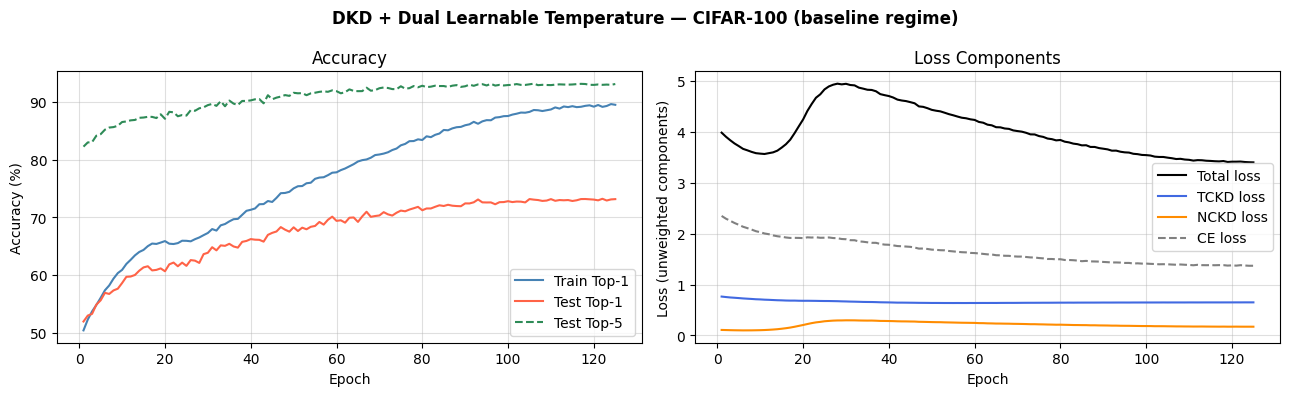

Curve data saved -> checkpoints/dkd_dual_temp_accuracy_loss_curves.json


In [22]:
ep = history['epoch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('DKD + Dual Learnable Temperature — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['train_acc'],  label='Train Top-1', color='steelblue')
axes[0].plot(ep, history['test_top1'],  label='Test Top-1',  color='tomato')
axes[0].plot(ep, history['test_top5'],  label='Test Top-5',  color='seagreen', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(ep, history['total_loss'], label='Total loss',  color='black')
axes[1].plot(ep, history['tckd_loss'],  label='TCKD loss',   color='royalblue')
axes[1].plot(ep, history['nckd_loss'],  label='NCKD loss',   color='darkorange')
axes[1].plot(ep, history['ce_loss'],    label='CE loss',     color='gray', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (unweighted components)')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

with open(CKPT_DIR / 'dkd_dual_temp_accuracy_loss_curves.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'train_acc': history['train_acc'],
               'test_top1': history['test_top1'], 'test_top5': history['test_top5'],
               'total_loss': history['total_loss'], 'tckd_loss': history['tckd_loss'],
               'nckd_loss': history['nckd_loss'], 'ce_loss': history['ce_loss']}, f, indent=2)
print(f'Curve data saved -> {CKPT_DIR / "dkd_dual_temp_accuracy_loss_curves.json"}')


### 12.2 Temperature Curriculum

The central diagnostic: do $\tau_{TCKD}$ and $\tau_{NCKD}$ evolve differently?

- If they **diverge**: the two DKD components require different temperature scales, validating the dual-temperature design.
- If $\tau_{TCKD}$ rises and $\tau_{NCKD}$ falls (or vice versa): the GRL is finding asymmetric optima.
- If they stay flat: consider increasing `LR_TEMP` or `GRL_LAMBDA_MAX`.


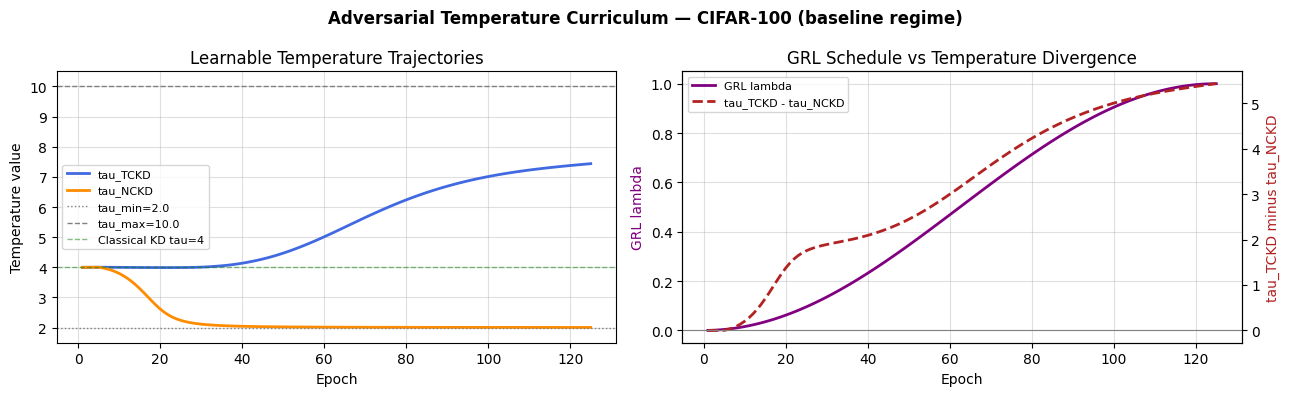

Temperature curriculum interpretation:
  Initial tau_TCKD : ~4.00  ->  Final: 7.438
  Initial tau_NCKD : ~4.00  ->  Final: 2.007
  Final divergence (TCKD - NCKD) : +5.431
Temperature data saved -> checkpoints/dkd_dual_temp_temperature_curriculum.json


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adversarial Temperature Curriculum — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['tau_tckd'], label='tau_TCKD', color='royalblue', linewidth=2)
axes[0].plot(ep, history['tau_nckd'], label='tau_NCKD', color='darkorange', linewidth=2)
axes[0].axhline(TAU_MIN, color='gray', linestyle=':', linewidth=1, label=f'tau_min={TAU_MIN}')
axes[0].axhline(TAU_MAX, color='gray', linestyle='--', linewidth=1, label=f'tau_max={TAU_MAX}')
axes[0].axhline(4.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Classical KD tau=4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Temperature value')
axes[0].set_title('Learnable Temperature Trajectories')
axes[0].set_ylim(TAU_MIN - 0.5, TAU_MAX + 0.5)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

ax2  = axes[1]
ax2b = ax2.twinx()
tau_diff = [t - n for t, n in zip(history['tau_tckd'], history['tau_nckd'])]
ax2.plot(ep,  history['grl_lambda'], color='purple',   linewidth=2, label='GRL lambda')
ax2b.plot(ep, tau_diff,              color='firebrick', linewidth=2, linestyle='--', label='tau_TCKD - tau_NCKD')
ax2b.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('GRL lambda', color='purple')
ax2b.set_ylabel('tau_TCKD minus tau_NCKD', color='firebrick')
ax2.set_title('GRL Schedule vs Temperature Divergence')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Temperature curriculum interpretation:')
print(f'  Initial tau_TCKD : ~4.00  ->  Final: {history["tau_tckd"][-1]:.3f}')
print(f'  Initial tau_NCKD : ~4.00  ->  Final: {history["tau_nckd"][-1]:.3f}')
print(f'  Final divergence (TCKD - NCKD) : {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.3f}')

with open(CKPT_DIR / 'dkd_dual_temp_temperature_curriculum.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'tau_tckd': history['tau_tckd'],
               'tau_nckd': history['tau_nckd'], 'tau_diff': tau_diff,
               'grl_lambda': history['grl_lambda'],
               'tau_min': float(TAU_MIN), 'tau_max': float(TAU_MAX)}, f, indent=2)
print(f'Temperature data saved -> {CKPT_DIR / "dkd_dual_temp_temperature_curriculum.json"}')


## 13. Results Summary

In [24]:
baseline_results = {
    'B1 ResNet-18 Teacher'          : {'top1': None, 'note': 'Teacher ceiling'},
    'B2 MobileNetV2 Vanilla'        : {'top1': None, 'note': 'Student w/o KD (retrained)'},
    'B3 MobileNetV2 + Classical KD' : {'top1': None, 'note': 'Primary baseline (retrained)'},
    'B4 DKD (cosine)'               : {'top1': None, 'note': 'DKD fixed tau, cosine regime'},
    'B5 CTKD (cosine)'              : {'top1': None, 'note': 'CTKD learnable tau, cosine regime'},
}

for ckpt_file, key in [
    ('b1_resnet18_teacher_cifar100.pth',            'B1 ResNet-18 Teacher'),
    ('b2_mobilenetv2_vanilla_cifar100.pth',         'B2 MobileNetV2 Vanilla'),
    ('b3_mobilenetv2_kd_cifar100.pth',              'B3 MobileNetV2 + Classical KD'),
    ('b4_mobilenetv2_dkd_cifar100_cosine.pth',      'B4 DKD (cosine)'),
    ('b5_mobilenetv2_ctkd_cifar100_cosine.pth',     'B5 CTKD (cosine)'),
]:
    path = CKPT_DIR / ckpt_file
    if path.exists():
        ckpt = torch.load(path, map_location='cpu')
        t1 = ckpt.get('top1', ckpt.get('val_top1', None))
        if t1:
            baseline_results[key]['top1'] = round(t1, 2)

rows = [{'Model': k, 'Top-1 (%)': v['top1'], 'Note': v['note']}
        for k, v in baseline_results.items()]
rows.append({
    'Model'     : 'B7 DKD + Dual MLP Temp, cosine (ours)',
    'Top-1 (%)' : round(best_top1, 2),
    'Note'      : (f'Best epoch {best_epoch}  |  '
                   f'tau_TCKD={history["tau_tckd"][best_epoch-1]:.2f}  '
                   f'tau_NCKD={history["tau_nckd"][best_epoch-1]:.2f}  '
                   f'label_smooth=0.1'),
})

df = pd.DataFrame(rows)
print('=' * 80)
print('CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)')
print('=' * 80)
print(df.to_string(index=False))
print('=' * 80)

b3_top1 = baseline_results['B3 MobileNetV2 + Classical KD']['top1']
if b3_top1 is not None:
    print(f'\nGain vs classical KD (B6 - B3): {best_top1 - b3_top1:+.2f}%')

with open(CKPT_DIR / 'dkd_dual_mlp_temp_results_summary.json', 'w') as f:
    json.dump({'baseline_results': baseline_results,
               'best': {'top1': round(best_top1, 2),
                        'top5': round(history['test_top5'][best_epoch-1], 2),
                        'epoch': best_epoch,
                        'tau_tckd': history['tau_tckd'][best_epoch-1],
                        'tau_nckd': history['tau_nckd'][best_epoch-1]}}, f, indent=2)
print(f'Results saved -> {CKPT_DIR / "dkd_dual_mlp_temp_results_summary.json"}')


CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)
                                Model  Top-1 (%)                                                              Note
                 B1 ResNet-18 Teacher        NaN                                                   Teacher ceiling
               B2 MobileNetV2 Vanilla        NaN                                        Student w/o KD (retrained)
        B3 MobileNetV2 + Classical KD        NaN                                      Primary baseline (retrained)
                      B4 DKD (cosine)        NaN                                      DKD fixed tau, cosine regime
                     B5 CTKD (cosine)        NaN                                 CTKD learnable tau, cosine regime
B7 DKD + Dual MLP Temp, cosine (ours)      73.21 Best epoch 122  |  tau_TCKD=7.40  tau_NCKD=2.01  label_smooth=0.1
Results saved -> checkpoints/dkd_dual_mlp_temp_results_summary.json


## 14. Full Training History Table

In [25]:
df_hist = pd.DataFrame({
    'Epoch'      : history['epoch'],
    'Total Loss' : [f'{v:.4f}' for v in history['total_loss']],
    'TCKD Loss'  : [f'{v:.4f}' for v in history['tckd_loss']],
    'NCKD Loss'  : [f'{v:.4f}' for v in history['nckd_loss']],
    'CE Loss'    : [f'{v:.4f}' for v in history['ce_loss']],
    'Train Acc'  : [f'{v:.2f}%' for v in history['train_acc']],
    'Test Top-1' : [f'{v:.2f}%' for v in history['test_top1']],
    'Test Top-5' : [f'{v:.2f}%' for v in history['test_top5']],
    'tau_TCKD'   : [f'{v:.3f}' for v in history['tau_tckd']],
    'tau_NCKD'   : [f'{v:.3f}' for v in history['tau_nckd']],
    'GRL lambda' : [f'{v:.3f}' for v in history['grl_lambda']],
})
print(df_hist.to_string(index=False))

with open(CKPT_DIR / 'dkd_dual_temp_epoch_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nEpoch-by-epoch history saved -> {CKPT_DIR / "dkd_dual_temp_epoch_history.json"}')


 Epoch Total Loss TCKD Loss NCKD Loss CE Loss Train Acc Test Top-1 Test Top-5 tau_TCKD tau_NCKD GRL lambda
     1     3.9800    0.7637    0.1088  2.3460    50.39%     51.93%     82.25%    4.001    4.001      0.000
     2     3.9005    0.7545    0.1067  2.2921    52.27%     52.96%     82.98%    4.001    4.001      0.001
     3     3.8315    0.7461    0.1043  2.2509    53.68%     53.25%     83.03%    4.002    4.002      0.001
     4     3.7682    0.7403    0.1025  2.2076    54.80%     54.86%     84.15%    4.003    4.003      0.003
     5     3.7164    0.7341    0.1013  2.1717    56.03%     55.60%     84.41%    4.003    4.003      0.004
     6     3.6617    0.7272    0.1001  2.1334    57.35%     56.90%     85.19%    4.003    3.981      0.006
     7     3.6333    0.7219    0.1006  2.1067    58.18%     56.71%     85.56%    4.002    3.949      0.008
     8     3.6023    0.7168    0.1010  2.0777    59.37%     57.32%     85.64%    4.001    3.909      0.010
     9     3.5773    0.7110    0.1025